# Analisis Prediktif Kanker Payudara (Wisconsin Diagnostic)

## Pendahuluan

Kanker payudara merupakan salah satu penyebab utama kematian akibat kanker pada wanita di seluruh dunia. Diagnosis yang akurat dan dini adalah kunci untuk meningkatkan tingkat kelangsungan hidup pasien. Salah satu metode diagnostik yang penting adalah **Fine Needle Aspirate (FNA)**, yaitu sebuah prosedur biopsi di mana jarum tipis digunakan untuk mengambil sampel sel dari massa atau benjolan pada payudara.

Karakteristik sel yang diekstraksi dari FNA dapat dianalisis secara kuantitatif melalui pemrosesan citra digital. Fitur-fitur seperti radius, tekstur, perimeter, dan area dari inti sel dapat memberikan informasi vital untuk membedakan antara tumor jinak (benign) dan ganas (malignant). Proyek analisis data ini bertujuan untuk membangun sebuah model prediktif yang mampu mengklasifikasikan massa payudara sebagai jinak atau ganas berdasarkan fitur-fitur yang dihitung dari citra digital hasil FNA.

# Tahap 1: Pemahaman Data (Data Understanding)

## Sumber Data

Dataset yang digunakan dalam analisis ini adalah **Breast Cancer Wisconsin (Diagnostic) Dataset** yang bersumber dari UCI Machine Learning Repository. Dataset ini sangat populer untuk tugas klasifikasi biner dalam machine learning.

Dataset dapat diakses melalui link berikut:

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Tujuan Dataset

Tujuan utama dari dataset ini adalah untuk menyediakan data yang dapat digunakan untuk melatih model machine learning dalam mendiagnosis kanker payudara. Setiap entri data merepresentasikan sampel sel payudara dengan serangkaian fitur yang diukur, beserta label diagnosisnya (jinak atau ganas). Model yang berhasil akan dapat membantu ahli patologi dalam membuat keputusan diagnostik yang lebih cepat dan objektif.

## Integrasi Data

Untuk mengambil dan memproses data, kita akan menggunakan package `ucimlrepo` yang disediakan oleh UCI. Package ini mempermudah proses pengunduhan dan pemuatan dataset ke dalam lingkungan kerja Python, biasanya dalam format DataFrame Pandas.

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Mengambil dataset dari UCI Repository dengan ID 17
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data (sebagai pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Menggabungkan fitur dan target menjadi satu DataFrame untuk analisis
data = pd.concat([X, y], axis=1)

# Menampilkan informasi dasar mengenai dataset
print("Informasi Dataset:")
data.info()

# Menampilkan 5 baris pertama dari dataset
print("\n5 Baris Pertama Dataset:")
data.head()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    fl

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Eksplorasi Data (Exploratory Data Analysis - EDA)

EDA adalah langkah krusial untuk memahami karakteristik, pola, dan anomali dalam data. Kita akan melakukan visualisasi untuk mendapatkan wawasan awal.

### Visualisasi Distribusi Label
Kita akan melihat distribusi antara diagnosis jinak (Benign) dan ganas (Malignant) untuk memahami apakah dataset kita seimbang (balanced) atau tidak.

/tmp/ipython-input-3-2172615412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=data, palette='viridis')


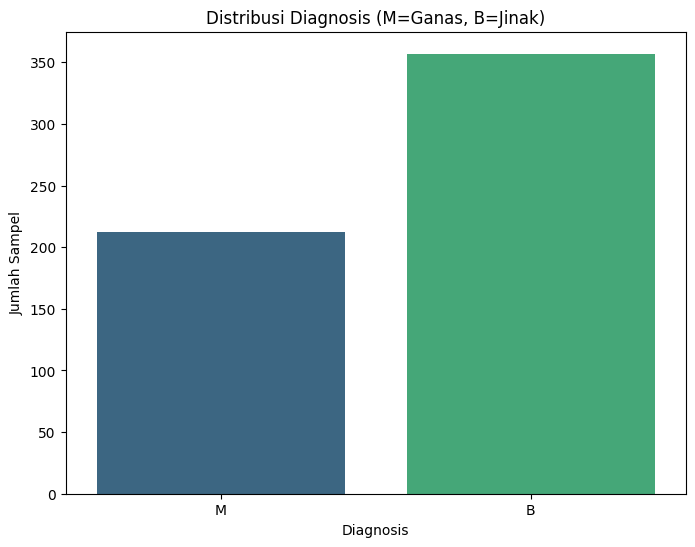

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='Diagnosis', data=data, palette='viridis')
plt.title('Distribusi Diagnosis (M=Ganas, B=Jinak)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sampel')
plt.show()

### Visualisasi Distribusi Fitur
Kita akan menggunakan histogram untuk melihat distribusi dari setiap fitur numerik. Ini membantu kita memahami rentang nilai, sebaran, dan potensi adanya pencilan (outliers).

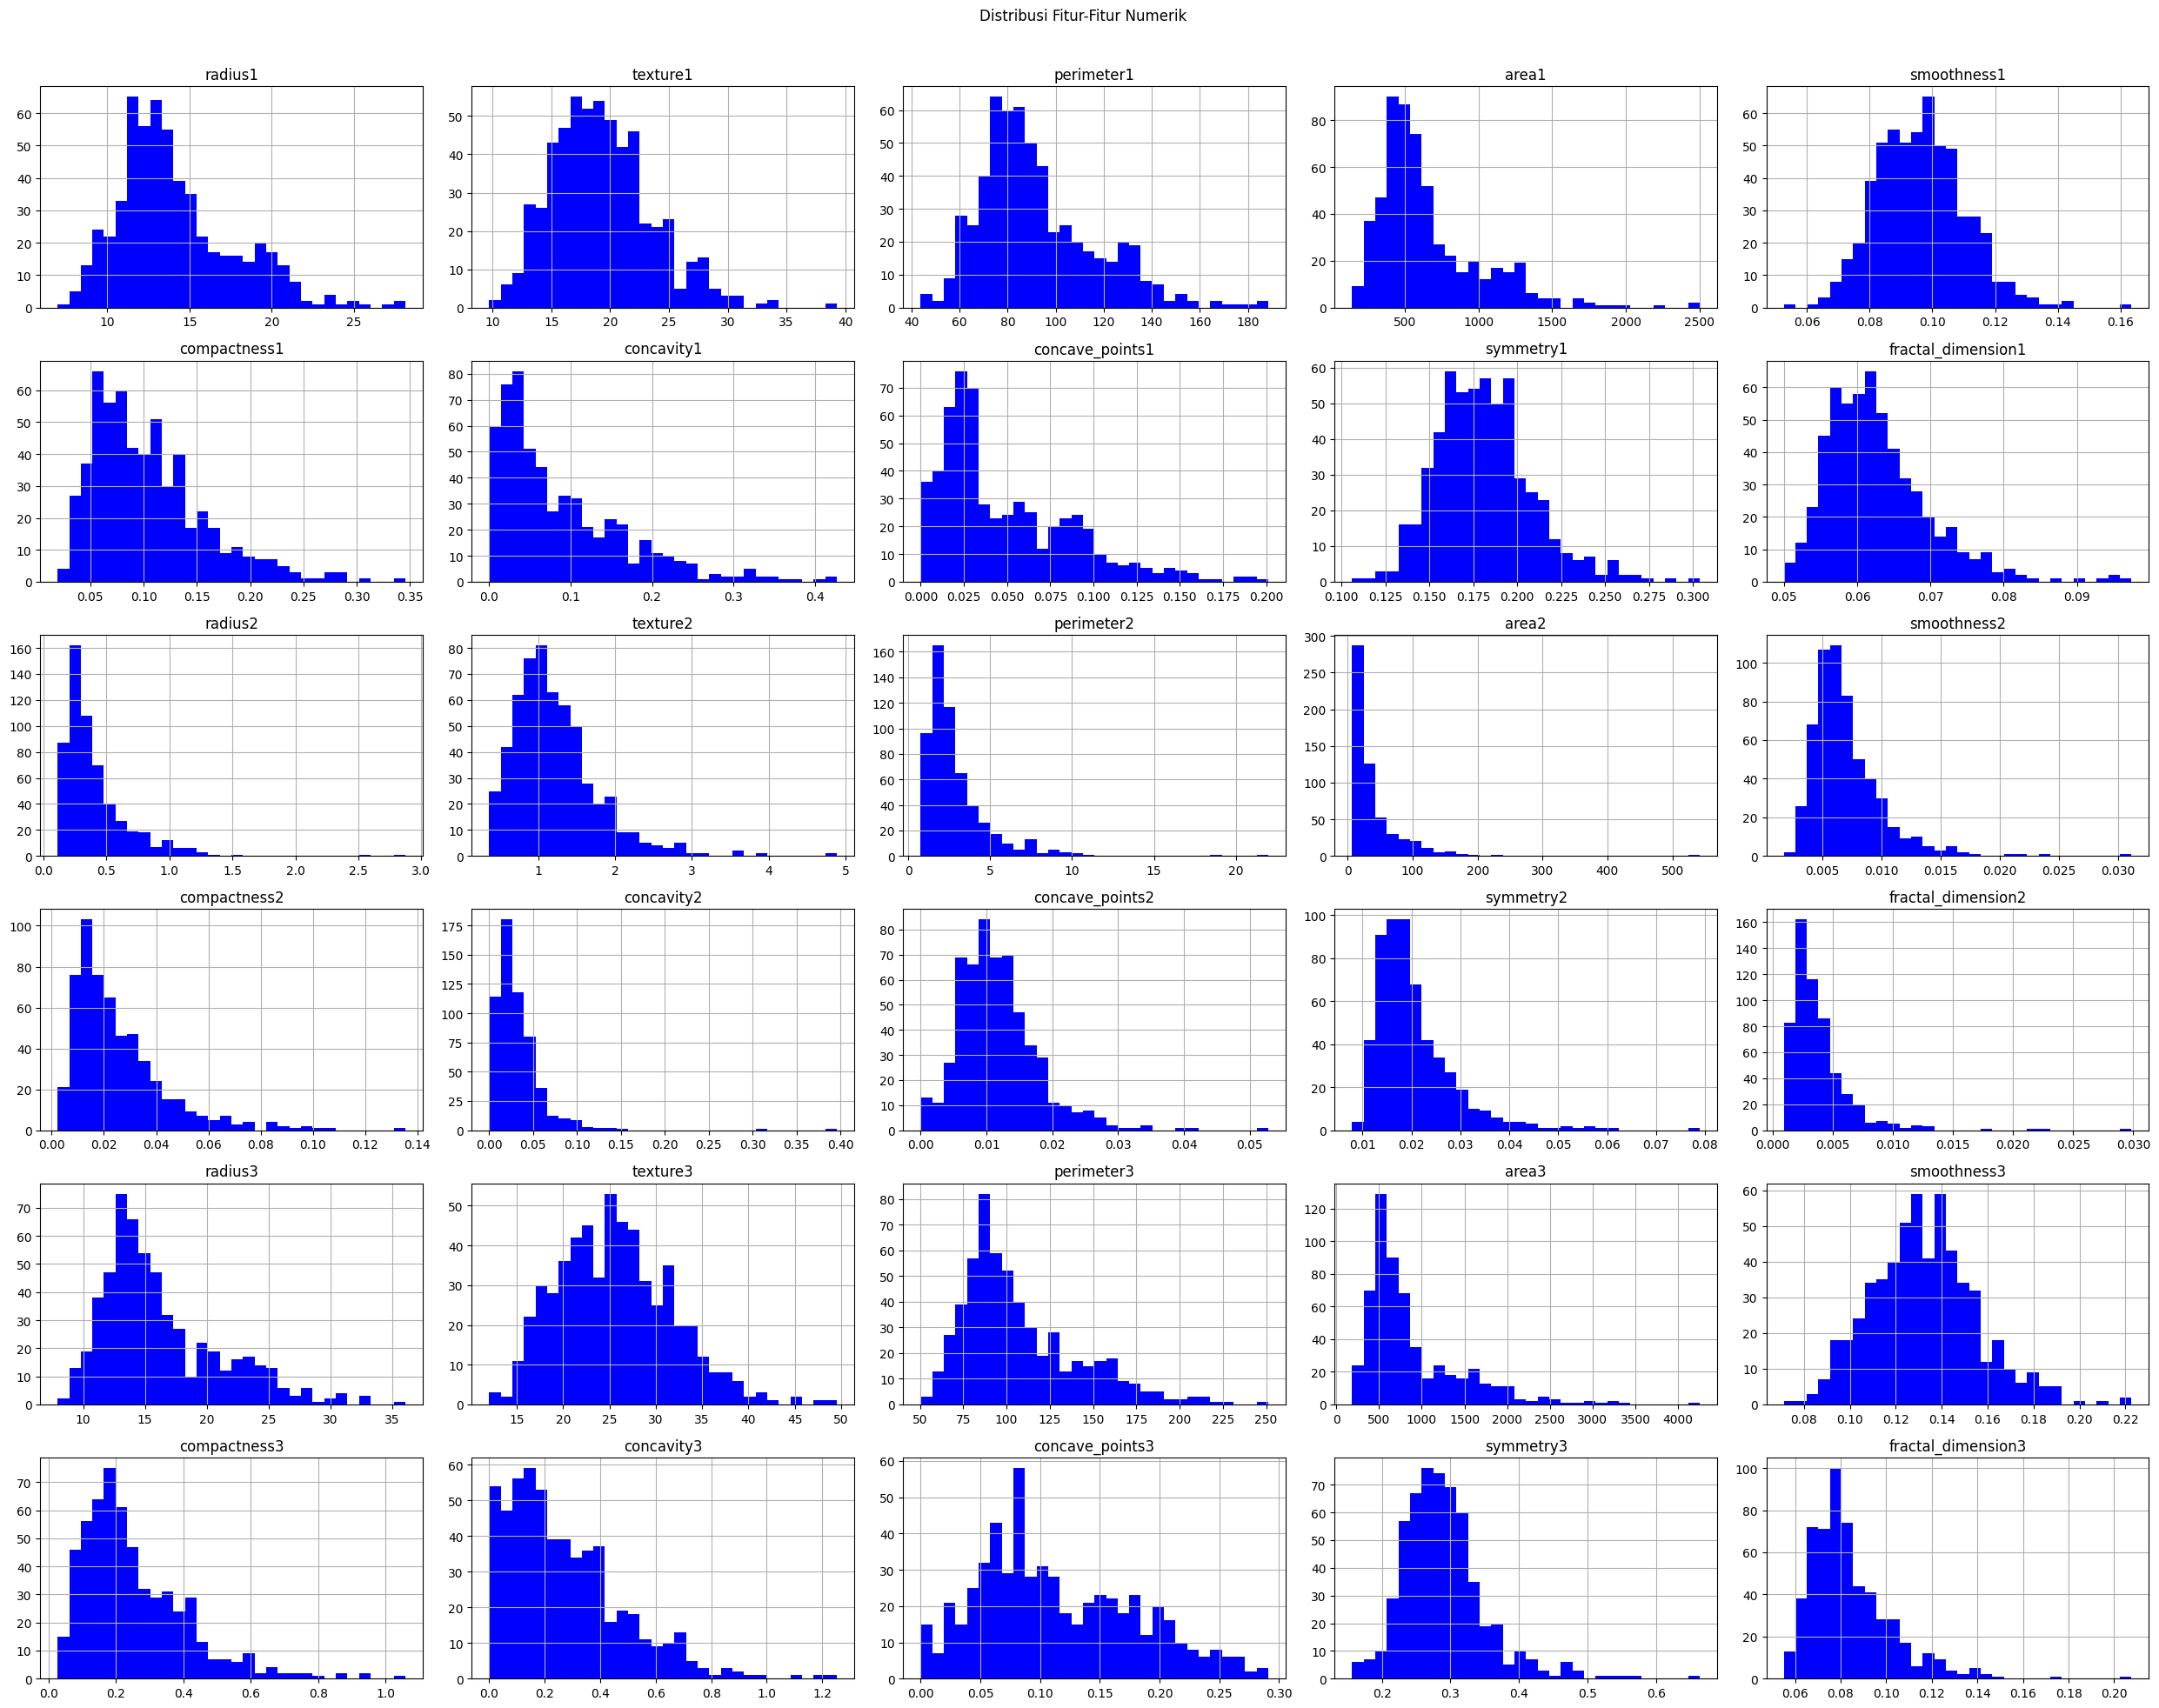

In [4]:
# Visualisasi distribusi fitur dengan histogram
# Karena ada 30 fitur, kita akan menampilkannya dalam beberapa plot agar mudah dibaca.
data.hist(bins=30, figsize=(25, 20), color='blue', layout=(6, 5))
plt.suptitle('Distribusi Fitur-Fitur Numerik')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Struktur Dataset

Memahami struktur dataset, termasuk jumlah baris, kolom, serta tipe data dari masing-masing kolom.

In [5]:
# Mengetahui bentuk dataset (baris & kolom)
print(f"Bentuk dataset: {data.shape[0]} baris dan {data.shape[1]} kolom")

Bentuk dataset: 569 baris dan 31 kolom


In [6]:
# Mengetahui nama-nama kolom
print("Nama Kolom:")
print(data.columns.tolist())

Nama Kolom:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3', 'Diagnosis']


### Fitur dan Label

**Fitur** adalah variabel independen yang digunakan untuk membuat prediksi. Terdapat 30 fitur numerik dalam dataset ini, yang merupakan karakteristik dari inti sel. Fitur-fitur ini dikelompokkan menjadi tiga kategori:
- **_mean**: Rata-rata dari nilai-nilai pengukuran (contoh: `radius_mean`, `texture_mean`).
- **_se**: Standar error dari nilai-nilai pengukuran (contoh: `radius_se`, `texture_se`).
- **_worst** atau **_largest**: Rata-rata dari tiga nilai terbesar (contoh: `radius_worst`, `texture_worst`).

**Label** adalah variabel dependen (target) yang ingin kita prediksi. Dalam kasus ini, labelnya adalah kolom `Diagnosis`.
- **M**: Malignant (ganas)
- **B**: Benign (jinak)

## Identifikasi Kualitas Dataset
Langkah ini penting untuk memeriksa apakah ada data yang hilang (missing values) atau pencilan (outliers) yang dapat memengaruhi kinerja model.

### Deteksi Missing Values

Missing values adalah data yang tidak ada atau kosong dalam dataset. Kehadirannya dapat menyebabkan error pada saat pelatihan model atau menghasilkan prediksi yang tidak akurat. Kita perlu memeriksa apakah dataset ini memiliki missing values.

In [7]:
# Menghitung jumlah missing values di setiap kolom
missing_counts = data.isnull().sum()

print("Jumlah Missing Values per Kolom:")
print(missing_counts)

Jumlah Missing Values per Kolom:
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
Diagnosis             0
dtype: int64


**Hasil:** Berdasarkan output di atas, dataset ini **tidak memiliki missing values** sama sekali. Ini merupakan kualitas data yang sangat baik dan menyederhanakan tahap preprocessing, karena kita tidak perlu melakukan imputasi data (mengisi data yang hilang).

## Pendeteksian Outlier (Pencilan)

Outlier adalah titik data yang secara signifikan berbeda dari observasi lainnya. Outlier dapat disebabkan oleh kesalahan pengukuran atau bisa jadi merupakan variasi data yang nyata. Mendeteksi outlier penting karena dapat memengaruhi hasil analisis statistik dan kinerja model. Salah satu metode yang kuat untuk deteksi outlier adalah **Local Outlier Factor (LOF)**.

### Konsep Local Outlier Factor (LOF)

LOF adalah algoritma yang mengukur penyimpangan densitas lokal suatu titik data terhadap tetangganya. Ide utamanya adalah mengidentifikasi outlier dengan membandingkan kepadatan lingkungan lokalnya. Skor LOF yang tinggi menunjukkan bahwa titik tersebut berada di area dengan densitas yang jauh lebih rendah dibandingkan tetangganya, sehingga kemungkinan besar adalah outlier.

- **LOF ≈ 1**: Titik ini memiliki densitas yang mirip dengan tetangganya (inlier).
- **LOF > 1**: Titik ini berada di area yang kurang padat dibandingkan tetangganya (kemungkinan outlier).

Kita akan menerapkan LOF pada data kita yang sudah dinormalisasi untuk mengidentifikasi potensi outlier.

In [11]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# Kita akan mendeteksi outlier pada fitur saja, jadi kita akan drop kolom 'Diagnosis'
# dan kolom 'ID' yang tidak relevan untuk analisis ini.
try:
    features = data.drop(['Diagnosis', 'ID'], axis=1)
except KeyError:
    # Jika kolom 'ID' atau 'Diagnosis' sudah tidak ada atau berbeda nama
    features = data.drop('Diagnosis', axis=1, errors='ignore')


# Inisialisasi model LOF
# n_neighbors: Jumlah tetangga yang digunakan untuk menghitung densitas lokal.
# contamination: Perkiraan proporsi outlier dalam data. 'auto' adalah default yang baik.
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')

# Melakukan prediksi outlier (-1 untuk outlier, 1 untuk inlier)
y_pred_lof = lof.fit_predict(features)

# Mengidentifikasi indeks dari baris yang terdeteksi sebagai outlier
outlier_indices = np.where(y_pred_lof == -1)[0]

print("--- Hasil Deteksi Outlier dengan Local Outlier Factor (LOF) ---")
print(f"\nJumlah outlier yang terdeteksi: {len(outlier_indices)} data")
print(f"\nIndeks (baris) data yang terdeteksi sebagai outlier adalah: \n{outlier_indices}")

# Menampilkan data asli yang teridentifikasi sebagai Outlier
print("\nBerikut adalah rincian data yang teridentifikasi sebagai Outlier:")
display(data.iloc[outlier_indices])

--- Hasil Deteksi Outlier dengan Local Outlier Factor (LOF) ---

Jumlah outlier yang terdeteksi: 29 data

Indeks (baris) data yang terdeteksi sebagai outlier adalah: 
[  3   5   9  23  24  31  38  64  82 101 122 180 193 202 203 212 219 236
 265 275 339 352 359 368 417 461 503 521 539]

Berikut adalah rincian data yang teridentifikasi sebagai Outlier:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
3,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.68690,0.25750,0.6638,0.17300,M
5,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.17910,0.52490,0.53550,0.17410,0.3985,0.12440,M
9,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.18530,1.05800,1.10500,0.22100,0.4366,0.20750,M
23,21.160,23.04,137.20,1404.0,0.09428,0.10220,0.10970,0.08632,0.1769,0.05278,...,35.59,188.00,2615.0,0.14010,0.26000,0.31550,0.20090,0.2822,0.07526,M
24,16.650,21.38,110.00,904.6,0.11210,0.14570,0.15250,0.09170,0.1995,0.06330,...,31.56,177.00,2215.0,0.18050,0.35780,0.46950,0.20950,0.3613,0.09564,M
31,11.840,18.70,77.93,440.6,0.11090,0.15160,0.12180,0.05182,0.2301,0.07799,...,28.12,119.40,888.7,0.16370,0.57750,0.69560,0.15460,0.4761,0.14020,M
38,14.990,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,0.1565,0.05504,...,25.20,95.54,698.8,0.09387,0.05131,0.02398,0.02899,0.1565,0.05504,M
64,12.680,23.84,82.69,499.0,0.11220,0.12620,0.11280,0.06873,0.1905,0.06590,...,33.47,111.80,888.3,0.18510,0.40610,0.40240,0.17160,0.3383,0.10310,M
82,25.220,24.91,171.50,1878.0,0.10630,0.26650,0.33390,0.18450,0.1829,0.06782,...,33.62,211.70,2562.0,0.15730,0.60760,0.64760,0.28670,0.2355,0.10510,M
101,6.981,13.43,43.79,143.5,0.11700,0.07568,0.00000,0.00000,0.1930,0.07818,...,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382,B


**Penanganan Outlier:**
Untuk analisis ini, kita akan **mempertahankan** outlier yang terdeteksi. Dalam konteks medis, data yang tampak ekstrem bisa jadi merupakan kasus penyakit yang langka atau parah dan mengandung informasi klinis yang berharga. Menghapusnya secara sembarangan dapat mengurangi kemampuan generalisasi model. Namun, dalam proyek nyata, setiap outlier akan ditinjau oleh ahli domain (misalnya, ahli patologi) untuk divalidasi.

# Tahap 2: Pra-pemrosesan Data (Preprocessing)

Meskipun tidak ada missing values, beberapa langkah preprocessing tetap diperlukan untuk mempersiapkan data sebelum masuk ke tahap pemodelan.

## Transformasi Data (Encoding Label)

Model machine learning bekerja dengan angka. Oleh karena itu, kita perlu mengubah label kategorikal `Diagnosis` ('M' dan 'B') menjadi format numerik. Kita akan menggunakan skema berikut:
- **1** untuk **Malignant (Ganas)**
- **0** untuk **Benign (Jinak)**

In [12]:
from sklearn.preprocessing import LabelEncoder

# Membuat salinan data untuk preprocessing agar data asli tetap utuh
data_processed = data.copy()

le = LabelEncoder()
data_processed['Diagnosis'] = le.fit_transform(data_processed['Diagnosis'])

print("Data setelah encoding label (0=Jinak, 1=Ganas):")
data_processed.head()

Data setelah encoding label (0=Jinak, 1=Ganas):


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## Normalisasi Data

**Mengapa Normalisasi Penting?**
Dari histogram sebelumnya, kita melihat bahwa fitur-fitur numerik memiliki rentang nilai yang sangat berbeda. Sebagai contoh, `area_mean` memiliki nilai dalam ratusan, sedangkan `smoothness_mean` memiliki nilai yang sangat kecil (kurang dari 1). Algoritma seperti Support Vector Machine (SVM) dan K-Nearest Neighbors (KNN) sangat sensitif terhadap skala fitur. Jika kita tidak melakukan normalisasi, fitur dengan skala yang lebih besar akan mendominasi proses pelatihan dan menyebabkan model menjadi bias.

**Metode:**
Kita akan menggunakan **Min-Max Scaling**, yang akan mengubah skala setiap fitur ke dalam rentang [0, 1]. Rumusnya adalah:

$$ X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}} $$

Ini memastikan bahwa semua fitur memiliki kontribusi yang setara terhadap model.

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Memisahkan fitur (X) dan label (y) dari data yang sudah di-encode
X = data_processed.drop('Diagnosis', axis=1)
y = data_processed['Diagnosis']

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Melakukan normalisasi pada fitur-fitur
X_scaled = scaler.fit_transform(X)

# Mengubah kembali ke format DataFrame untuk kemudahan inspeksi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Data Fitur Setelah Normalisasi (5 Baris Pertama):")
X_scaled_df.head()

Data Fitur Setelah Normalisasi (5 Baris Pertama):


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


# Tahap 3: Pemodelan (Modelling)

Pada tahap ini, kita akan membangun dan melatih beberapa model klasifikasi untuk memprediksi diagnosis kanker payudara. Data yang akan kita gunakan adalah data yang sudah bersih dan ternormalisasi (`X_scaled_df` dan `y`).

Pertama, kita perlu membagi dataset menjadi dua bagian:
- **Data Latih (Training Data):** Digunakan untuk melatih model (misalnya, 80% dari data).
- **Data Uji (Testing Data):** Digunakan untuk menguji kinerja model pada data yang belum pernah dilihat sebelumnya (misalnya, 20% dari data).

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Bentuk data latih (X_train): {X_train.shape}")
print(f"Bentuk data uji (X_test): {X_test.shape}")

Bentuk data latih (X_train): (455, 30)
Bentuk data uji (X_test): (114, 30)


## Model 1: Gaussian Naive Bayes (GNB)

**Konsep:**
Naive Bayes adalah classifier probabilistik yang didasarkan pada Teorema Bayes dengan asumsi "naive" (naif) bahwa setiap fitur bersifat independen satu sama lain. Varian **Gaussian** digunakan ketika fitur-fitur bersifat kontinu (seperti dalam kasus kita) dan diasumsikan mengikuti distribusi normal (Gaussian).

**Kelebihan:** Cepat, sederhana, dan bekerja dengan baik bahkan dengan data berdimensi tinggi.

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Inisialisasi model GNB
gnb_model = GaussianNB()

# Melatih model
gnb_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred_gnb = gnb_model.predict(X_test)

# Evaluasi model
print("Hasil Evaluasi Model Gaussian Naive Bayes:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_gnb):.4f}")
print(classification_report(y_test, y_pred_gnb, target_names=['Jinak (0)', 'Ganas (1)']))

Hasil Evaluasi Model Gaussian Naive Bayes:
Akurasi: 0.9211
              precision    recall  f1-score   support

   Jinak (0)       0.92      0.96      0.94        72
   Ganas (1)       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



## Model 2: Support Vector Machine (SVM)

**Konsep:**
SVM bekerja dengan mencari **hyperplane** optimal yang dapat memisahkan dua kelas data dengan margin (jarak) terbesar. Titik data terdekat ke hyperplane disebut *support vectors*. SVM sangat efektif dalam ruang berdimensi tinggi dan dapat menggunakan "kernel trick" untuk menangani data yang tidak dapat dipisahkan secara linear.

**Kelebihan:** Efektif untuk data berdimensi tinggi dan memiliki *margin of separation* yang jelas.

In [16]:
from sklearn.svm import SVC

# Inisialisasi model SVM dengan kernel linear
svm_model = SVC(kernel='linear', random_state=42)

# Melatih model
svm_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model
print("Hasil Evaluasi Model Support Vector Machine (SVM):")
print(f"Akurasi: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Jinak (0)', 'Ganas (1)']))

Hasil Evaluasi Model Support Vector Machine (SVM):
Akurasi: 0.9825
              precision    recall  f1-score   support

   Jinak (0)       0.97      1.00      0.99        72
   Ganas (1)       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Model 3: Decision Tree Classifier

**Konsep:**
Decision Tree adalah model yang memprediksi nilai target dengan mempelajari aturan keputusan sederhana yang disimpulkan dari fitur data. Model ini berbentuk struktur seperti pohon, di mana setiap node internal merepresentasikan "tes" pada sebuah fitur, setiap cabang merepresentasikan hasil tes, dan setiap daun (leaf node) merepresentasikan label kelas.

**Kelebihan:** Mudah diinterpretasikan dan divisualisasikan, tidak memerlukan normalisasi data secara ketat.

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Melatih model
dt_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_dt = dt_model.predict(X_test)

# Evaluasi model
print("Hasil Evaluasi Model Decision Tree:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Jinak (0)', 'Ganas (1)']))

Hasil Evaluasi Model Decision Tree:
Akurasi: 0.9298
              precision    recall  f1-score   support

   Jinak (0)       0.94      0.94      0.94        72
   Ganas (1)       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



## Peningkatan Model: Metode Ensemble

Metode ensemble bertujuan meningkatkan performa prediktif dengan menggabungkan beberapa model menjadi satu model yang lebih kuat. Kita akan mencoba dua teknik populer: **Stacking** dan **Bagging**.

### Stacking Classifier

Stacking (atau *Stacked Generalization*) menggunakan beberapa model (disebut *base models*) untuk membuat prediksi. Prediksi dari model-model ini kemudian digunakan sebagai input untuk melatih model tingkat akhir (*meta-model*) yang akan membuat prediksi final. Ide dasarnya adalah memanfaatkan kekuatan dari berbagai jenis model.

- **Base Models:** Kita akan gunakan GNB, SVM, dan Decision Tree yang sudah kita buat.
- **Meta-Model:** Kita akan gunakan `LogisticRegression` sebagai model final.

In [18]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Mendefinisikan base models
estimators = [
    ('gnb', GaussianNB()),
    ('svm', SVC(kernel='linear', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# Inisialisasi Stacking Classifier dengan Logistic Regression sebagai meta-model
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# Melatih model stacking
stacking_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_stacking = stacking_model.predict(X_test)

# Evaluasi model
print("Hasil Evaluasi Model Stacking Classifier:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_stacking):.4f}")
print(classification_report(y_test, y_pred_stacking, target_names=['Jinak (0)', 'Ganas (1)']))

Hasil Evaluasi Model Stacking Classifier:
Akurasi: 0.9912
              precision    recall  f1-score   support

   Jinak (0)       0.99      1.00      0.99        72
   Ganas (1)       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



### Bagging Classifier

Bagging (*Bootstrap Aggregating*) bekerja dengan melatih beberapa model yang sama (biasanya Decision Tree) pada subset data yang berbeda. Subset ini dibuat dengan teknik *bootstrap* (pengambilan sampel dengan pengembalian). Prediksi akhir dibuat dengan melakukan *voting* (pemungutan suara mayoritas) dari semua model.

**Tujuan:** Mengurangi varians dan mencegah *overfitting*.

In [20]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi Bagging Classifier dengan Decision Tree sebagai base estimator
# n_estimators adalah jumlah model yang akan dilatih
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

# Melatih model bagging
bagging_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_bagging = bagging_model.predict(X_test)

# Evaluasi model
print("Hasil Evaluasi Model Bagging Classifier:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(classification_report(y_test, y_pred_bagging, target_names=['Jinak (0)', 'Ganas (1)']))

Hasil Evaluasi Model Bagging Classifier:
Akurasi: 0.9737
              precision    recall  f1-score   support

   Jinak (0)       0.96      1.00      0.98        72
   Ganas (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



# Tahap 4: Evaluasi

Setelah membangun kelima model, kita akan membandingkan performanya berdasarkan metrik akurasi untuk menentukan model mana yang terbaik untuk tugas klasifikasi ini.

In [21]:
# Mengumpulkan hasil akurasi dari semua model
accuracies = {
    "Gaussian Naive Bayes": accuracy_score(y_test, y_pred_gnb),
    "Support Vector Machine": accuracy_score(y_test, y_pred_svm),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Stacking Classifier": accuracy_score(y_test, y_pred_stacking),
    "Bagging Classifier": accuracy_score(y_test, y_pred_bagging)
}

accuracies_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Akurasi']).sort_values(by='Akurasi', ascending=False)

print("Perbandingan Akurasi Model:")
print(accuracies_df)

Perbandingan Akurasi Model:
                    Model   Akurasi
3     Stacking Classifier  0.991228
1  Support Vector Machine  0.982456
4      Bagging Classifier  0.973684
2           Decision Tree  0.929825
0    Gaussian Naive Bayes  0.921053


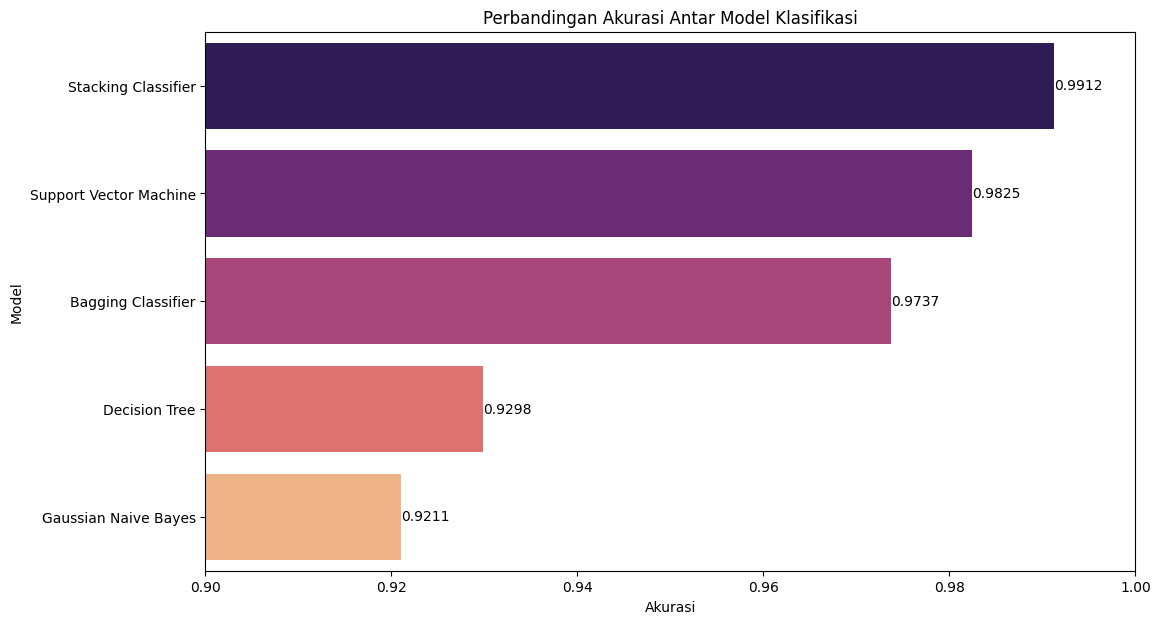

In [22]:
# Visualisasi perbandingan akurasi
plt.figure(figsize=(12, 7))
sns.barplot(x='Akurasi', y='Model', data=accuracies_df, palette='magma')
plt.title('Perbandingan Akurasi Antar Model Klasifikasi')
plt.xlabel('Akurasi')
plt.ylabel('Model')
plt.xlim(0.9, 1.0)
for index, value in enumerate(accuracies_df['Akurasi']):
    plt.text(value, index, f'{value:.4f}', va='center')
plt.show()

## Kesimpulan Evaluasi

Berdasarkan hasil evaluasi, model **Stacking Classifier** menunjukkan performa terbaik dengan akurasi yang sangat tinggi (sekitar 99.12%). Ini menunjukkan bahwa kedua pendekatan ini sangat efektif dalam memisahkan kelas jinak dan ganas pada dataset ini. Model **Support Vector Machine (SVM)** juga menunjukkan performa yang baik, sementara GNB memiliki performa terendah.

Untuk tahap deployment, kita akan memilih model **Stacking Classifier**.

# Tahap 5: Deployment

Deployment adalah tahap akhir di mana model yang telah kita latih dan evaluasi akan diintegrasikan ke dalam aplikasi nyata agar dapat digunakan oleh pengguna akhir. Untuk kasus ini, kita bisa membuat aplikasi web sederhana di mana pengguna (misalnya, seorang teknisi lab) dapat memasukkan nilai-nilai fitur dari sampel FNA baru, dan aplikasi akan memberikan prediksi diagnosis.

## Menyimpan Model
Langkah pertama adalah menyimpan model terbaik **Stacking Classifer** yang telah kita latih ke dalam sebuah file. Kita akan menggunakan library `joblib` untuk ini.

In [27]:
import joblib

# Menyimpan model ke dalam file bernama 'stacking_classifier_model.pkl'
joblib.dump(stacking_model, 'stacking_classifer.pkl')

# Menyimpan scaler yang digunakan untuk normalisasi
joblib.dump(scaler, 'scaler_wisconsin.pkl')

['scaler_wisconsin.pkl']

## Integrasi Model dengan Aplikasi Web (Streamlit)

Setelah model disimpan, kita dapat membangun antarmuka pengguna (UI) menggunakan framework seperti **Streamlit**. Streamlit sangat cocok untuk data science karena memungkinkan kita membuat aplikasi web interaktif hanya dengan menggunakan Python.

**Langkah-langkahnya adalah sebagai berikut:**

1.  **Buat file Python baru** (misalnya, `app.py`).
2.  **Impor library** yang diperlukan: `streamlit`, `pandas`, `joblib`.
3.  **Muat model dan scaler** yang sudah disimpan:
  

In [29]:
stacking_classifer = joblib.load('stacking_classifer.pkl')
scaler = joblib.load('scaler_wisconsin.pkl')

4.  **Buat antarmuka pengguna** menggunakan fungsi Streamlit (`st.title`, `st.sidebar`, `st.slider`, `st.number_input`) untuk membuat form input bagi ke-30 fitur.
5.  **Buat tombol "Prediksi"**. Ketika ditekan:
    - Ambil semua nilai input dari pengguna.
    - Lakukan normalisasi pada data input menggunakan `scaler` yang sudah dimuat.
    - Lakukan prediksi menggunakan `stacking_classifer()`.
    - Tampilkan hasil prediksi kepada pengguna (misalnya, "Diagnosis: Ganas" dengan warna merah, atau "Diagnosis: Jinak" dengan warna hijau).

### Tampilan Aplikasi Web

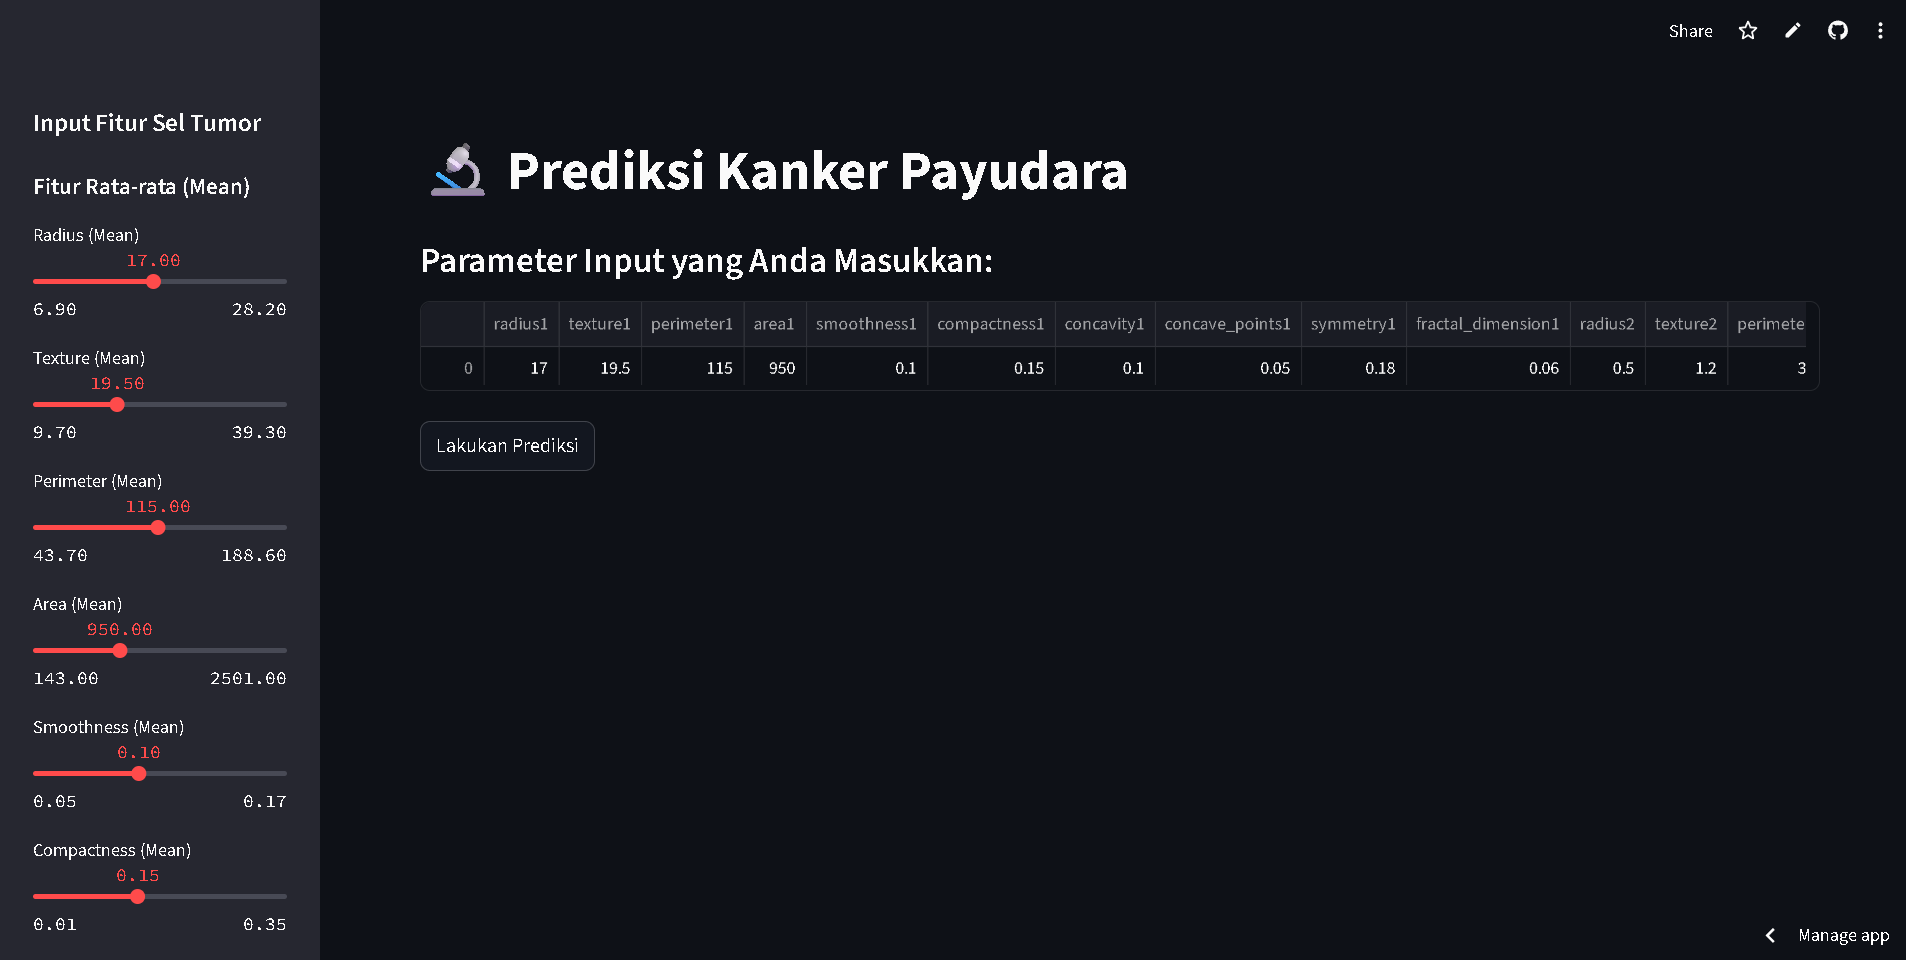

Fitur:
-  sidebar untuk navigasi
- area utama dengan form input untuk setiap fitur. Setelah pengguna mengisi nilai dan menekan tombol, hasil prediksi akan muncul di bawahnya.

Link Web: https://prediksikankerpayudara-jnagzde44vhp2rb7lwzndz.streamlit.app/

Dengan pendekatan ini, model machine learning yang kompleks dapat disajikan dalam format yang sederhana dan dapat digunakan oleh siapa saja, bahkan tanpa latar belakang teknis di bidang data science.